# BEE 4750 Lab 2: Monte Carlo

**Name**: Matthew Burgos

**ID**: mb2557

> **Due Date**
>
> Thursday, 10/02/25, 9:00pm

## Setup

The following code should go at the top of most Julia scripts; it will
load the local package environment and install any needed packages. You
will see this often and shouldn’t need to touch it.

In [99]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Desktop/lab-2-mb2557-droid`


In [100]:
using Random # random number generation
using Distributions # probability distributions and interface
using Statistics # basic statistical functions, including mean
using Plots # plotting

## Overview

In this lab, we will conduct a Monte Carlo experiment and explore how
sensitive Monte Carlo estimates are to the underlying probability
distribution(s).

You should always start any computing with random numbers by setting a
“seed,” which controls the sequence of numbers which are generated
(since these are not *really* random, just “pseudorandom”). In Julia, we
do this with the `Random.seed!()` function.

In [101]:
Random.seed!(3)

TaskLocalRNG()

It doesn’t matter what seed you set, though different seeds might result
in slightly different values. But setting a seed means every time your
notebook is run, the answer will be the same.

> **Seeds and Reproducing Solutions**
>
> If you don’t re-run your code in the same order or if you re-run the
> same cell repeatedly, you will not get the same solution. If you’re
> working on a specific problem, you might want to re-use
> `Random.seed()` near any block of code you want to re-evaluate
> repeatedly.

### Probability Distributions and Julia

Julia provides a common interface for probability distributions with the
[`Distributions.jl`
package](https://juliastats.org/Distributions.jl/stable/). The basic
workflow for sampling from a distribution is:

1.  Set up the distribution. The specific syntax depends on the
    distribution and what parameters are required, but the general call
    is the similar. For a normal distribution or a uniform distribution,
    the syntax is

    ``` julia
    # you don't have to name this "normal_distribution"
    # μ is the mean and σ is the standard deviation
    normal_distribution = Normal(μ, σ)
    # a is the upper bound and b is the lower bound; these can be set to +Inf or -Inf for an unbounded distribution in one or both directions.
    uniform_distribution = Uniform(a, b)
    ```

    There are lots of both
    [univariate](https://juliastats.org/Distributions.jl/stable/univariate/#Index)
    and
    [multivariate](https://juliastats.org/Distributions.jl/stable/multivariate/)
    distributions, as well as the ability to create your own, but we
    won’t do anything too exotic here.

2.  Draw samples. This uses the `rand()` command (which, when used
    without a distribution, just samples uniformly from the interval
    $[0, 1]$.) For example, to sample from our normal distribution
    above:

    ``` julia
    # draw n samples
    rand(normal_distribution, n)
    ```

Putting this together, let’s say that we wanted to simulate 100
six-sided dice rolls. We could use a [Discrete Uniform
distribution](https://juliastats.org/Distributions.jl/stable/univariate/#Distributions.DiscreteUniform).

In [102]:
dice_dist = DiscreteUniform(1, 6) # can generate any integer between 1 and 6
dice_rolls = rand(dice_dist, 100) # simulate rolls

100-element Vector{Int64}:
 3
 6
 6
 1
 5
 3
 6
 5
 5
 4
 ⋮
 4
 2
 6
 3
 6
 5
 4
 5
 2

And then we can plot a histogram of these rolls:

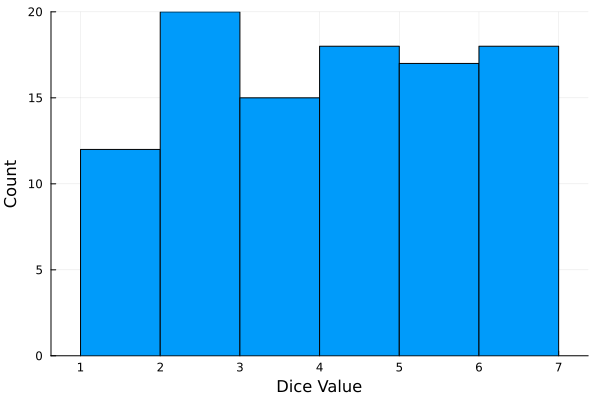

In [103]:
histogram(dice_rolls, legend=:false, bins=6)
ylabel!("Count")
xlabel!("Dice Value")

### Instructions

**Remember to**:

-   Evaluate all of your code cells, in order (using a `Run All`
    command). This will make sure all output is visible and that the
    code cells were evaluated in the correct order.
-   Tag each of the problems when you submit to Gradescope; a 10%
    penalty will be deducted if this is not done.

## Problem

A common engineering problem is to quantify flood risk, which is
typically computed by propagating a flood hazard distribution through a
*depth-damage function* relating flood depths to economic damages. A
reasonable depth-damage function for a house without a basement is a
bounded logistic function,
$$d(h) = \mathbb{1}_{h > 0} \frac{L}{1 + \exp(-k (h - h_0))},$$

where $d$ is the damage as a percent of total structure value, $h$ is
the water depth (relative to the house’s ground floor elevation) in m,
$\mathbb{1}_{x > 0}$ is the indicator function, $L$ is the maximum loss
in USD, $k$ is the slope of the depth-damage relationship, and $h_0$ is
the inflection point. We’ll assume $L=\$200,000$, $k=0.8$, and $h_0=3$.

For this problem, suppose that we have two different probability
distributions characterizing annual maxima flood depths:

1.  $h \sim LogNormal(1.2, 0.3)$;
2.  $h \sim GeneralizedExtremeValue(3, 0.9, -0.15)$.

Plot histograms of samples from these distributions and conduct a Monte
Carlo experiment for annual maximum flood damages using each. Answer the
following questions:

-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?
-   How did you decide on your sample size?
-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

In my code below, I took random samples of each distribution and plotted them. Then, I calculated the damage for each sample and plotted those. I computed the expected value by taking the mean of the damages, and I computed the 99th percentile by sorting the arrays and printing the 99th percentile data point.

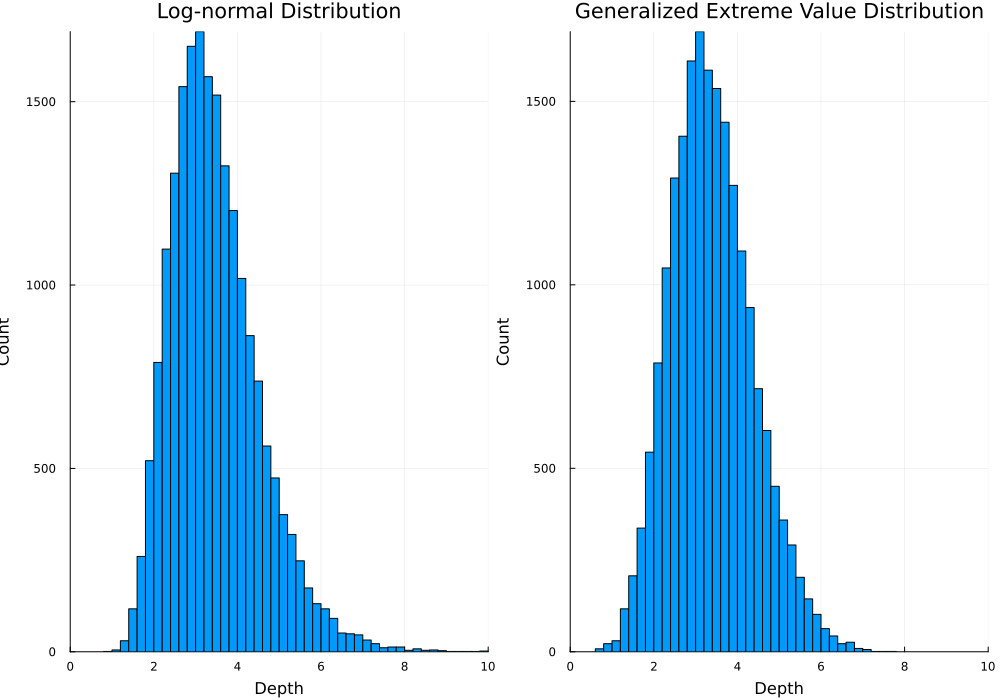

In [104]:
# Take random sample from both distributions
num_samples = 20000
distr1 = LogNormal(1.2, 0.3)
distr2 = GeneralizedExtremeValue(3, 0.9, -0.15)
h_lognormal = rand(distr1, num_samples)
h_gev = rand(distr2, num_samples)

# Plot histograms
p1 = histogram(h_lognormal, legend=:false, bins=50, title="Log-normal Distribution", ylabel="Count", xlabel="Depth", xlims=(0,10))
p2 = histogram(h_gev, legend=:false, bins=50, title="Generalized Extreme Value Distribution", ylabel="Count", xlabel="Depth", xlims=(0,10))


plot(p1, p2, size = (1000, 700))

Expected value of log-normal distribution 11522.063563731017 dollars
Expected value of generalized extreme value distribution 11316.726871763398 dollars
99% quantile of log-normal distribution 18976.360205238674 dollars
99% quantile of generalized extreme value distribution 18230.18650307948 dollars

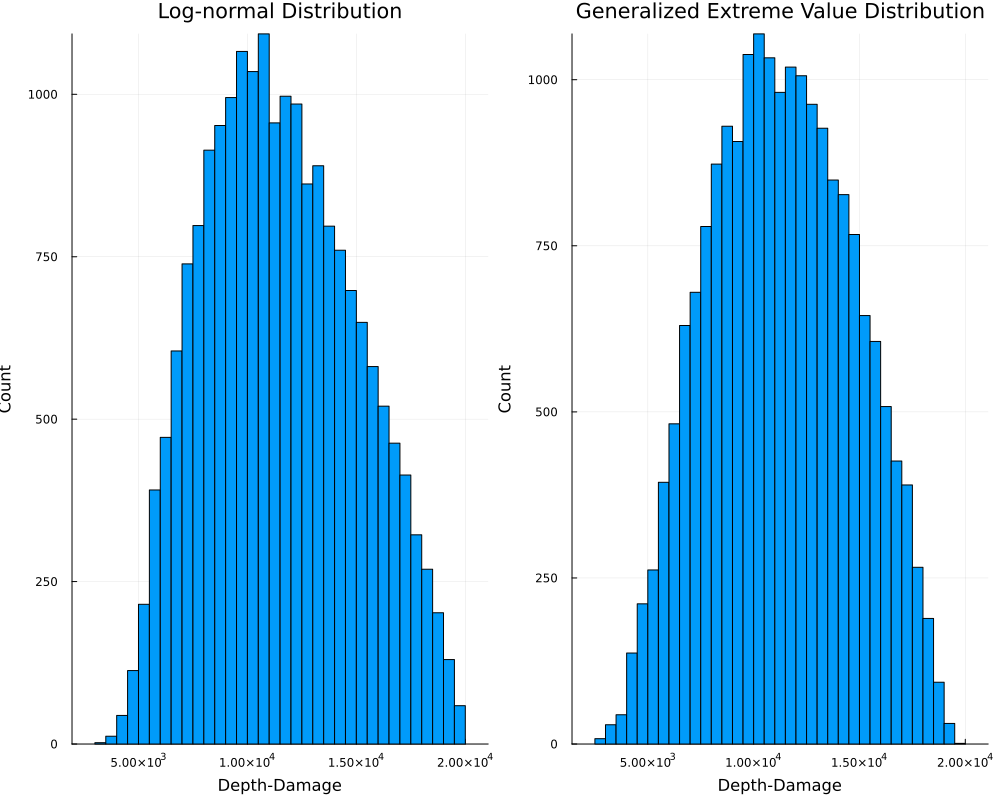

In [105]:
# Given information
L = 20000
k = 0.8
h0 = 3

function damage(data)
    # Returns array damage based on the depth-damage function
    # remove any negative values
    positives = filter(x -> x >= 0, data)
    damages = zeros(length(positives))
    # Calculate damage for each depth
    for i in 1:length(positives)
        damages[i] = L / (1+exp(-k*(positives[i]-h0)))
    end
    return damages
end

damage_lognormal = sort(damage(h_lognormal))
damage_gev = sort(damage(h_gev))

# Expected values of each distribution
print("Expected value of log-normal distribution " * string(mean(damage_lognormal)) * " dollars")
print("\n")
print("Expected value of generalized extreme value distribution " * string(mean(damage_gev)) * " dollars")

# 99% quantile of each distribution
index99_log = round(Int, 0.99 * length(damage_lognormal))
index99_gev = round(Int, 0.99 * length(damage_gev))
print("\n")
print("99% quantile of log-normal distribution " * string(damage_lognormal[index99_log]) * " dollars")
print("\n")
print("99% quantile of generalized extreme value distribution " * string(damage_gev[index99_gev]) * " dollars")

# Plot historgrams
p1 = histogram(damage_lognormal, legend=:false, bins=50, title="Log-normal Distribution", ylabel="Count", xlabel="Depth-Damage")
p2 = histogram(damage_gev, legend=:false, bins=50, title="Generalized Extreme Value Distribution", ylabel="Count", xlabel="Depth-Damage")
plot(p1, p2, size = (1000, 800))


-   What are the Monte Carlo estimates of the expected value and the 99%
    quantile for the annual maximum damage the structure would suffer
    for each of these flood hazard distributions?

Expected value of log-normal distribution 11522.063563731017 dollars

Expected value of generalized extreme value distribution 11316.726871763398 dollars

99% quantile of log-normal distribution 18976.360205238674 dollars

99% quantile of generalized extreme value distribution 18230.18650307948 dollars

    
-   How did you decide on your sample size?

I made my sample size to be 20,000 samples for each distribution. I decided on this sample size by testing different sample sizes and inspecting the outputted graph. I researched what log-normal distributions and generalized extreme value distributions are supposed to look like, and compared that with my graphs. It seemed like 20,000 samples sufficiently created a curve representative of my expectations. I made sure that there were no sudden jumps in my depth historgram. I also made sure that the processing time was less than a few seconds, so I could run my code without waiting too long. Once I completed all code, I repeated it a few times with different seeds to check that my expected values and 99th percentiles remained around the same values (+-100 dollars).

-   Why do you think the estimates differed or did not differ (you can
    also plot the depth-damage function to compare with the samples)?

The log-normal distribution has slightly larger expected damages and larger 99th percentile damages. It is difficult to tell why one is larger than the other based on the histograms, but one can see some slight differences in the distributions. Looking at the first set of histograms, extreme values seems to be more common in the log-normal distribution, especially on the right tail. This could explain why the 99th quartile is larger for the log-normal distribution (the variance is larger). This could also explain the slightly larger expected value.
    
-   How might you decide (based on getting additional information, if
    needed) which distribution is “better”?

One could decide which distribution is better by comparing it to historical data on depth-damages to homes without a basement. Given a dataset of actual flood depths and corresponding damage costs, you could compute the root-mean-squared error, or other error measurements, for each distribution. This would be done by comparing the actual damage cost to the expected cost. The distribution with the smaller root-mean-squared error can be considered "better."

## References

Put any consulted sources here, including classmates you worked with/who
helped you.

Lognormal Distribution: https://en.wikipedia.org/wiki/Log-normal_distribution
GEV Distribution: https://en.wikipedia.org/wiki/Generalized_extreme_value_distribution
